# Objective

Nike invests millions in sponsoring football players. Traditionally, sponsorship decisions are influenced by popularity and reputation. However, using player performance data can help identify emerging talents who provide greater marketing value at lower investment costs.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv("players.csv")

df.head()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,27-002,1999,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23-046,2003,NaN,1,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amine Gouiri,Algeria,Algeria,FW,26-121,2000,Marseille,1,1,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anis Hadj Moussa,Algeria,Algeria,MF,24-126,2002,Feyenoord,1,1,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aïssa Mandi,Algeria,Algeria,DF,34-238,1991,Lille,1,1,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dataset Overview

In [7]:
df.shape

(1035, 72)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1035 non-null   object 
 1   team                        1035 non-null   object 
 2   team_country                1035 non-null   object 
 3   position                    1035 non-null   object 
 4   age                         1035 non-null   object 
 5   birth_year                  1035 non-null   int64  
 6   club                        556 non-null    object 
 7   games                       1035 non-null   int64  
 8   games_starts                1035 non-null   int64  
 9   minutes                     627 non-null    float64
 10  minutes_90s                 627 non-null    float64
 11  goals                       627 non-null    float64
 12  assists                     627 non-null    float64
 13  goals_assists               627 n

In [9]:
df.describe()

,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
count,1035.000000,1035.000000,1035.000000,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.0,40.0,3.0
mean,1998.168116,0.605797,0.425121,63.079745,0.700957,0.092504,0.071770,0.164274,0.087719,0.004785,...,0.300000,0.400000,0.300000,0.175000,17.500000,0.075000,0.075000,0.0,0.0,0.0
std,4.264326,0.488915,0.494600,31.342232,0.349668,0.335909,0.287576,0.455845,0.325133,0.069061,...,0.464095,0.496139,0.464095,0.384808,38.480764,0.266747,0.266747,0.0,0.0,0.0
min,1982.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
25%,1995.000000,0.000000,0.000000,30.000000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
50%,1998.000000,1.000000,0.000000,79.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
75%,2001.000000,1.000000,1.000000,90.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
max,2008.000000,1.000000,1.000000,90.000000,1.000000,3.000000,2.000000,3.000000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,0.0,0.0,0.0


In [10]:
df.columns

Index(['player', 'team', 'team_country', 'position', 'age', 'birth_year',
       'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals',
       'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att',
       'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_game', 'minutes_pct', 'minutes_per_start',
       'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs',
       'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus',
       'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls',
       'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won',
       'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts',
       'gk_minutes', 'gk_goals_against', 

# Data Understanding

In [11]:
print("Players :", df["player"].nunique())
print("Countries :", df["team"].nunique())
print("Clubs :", df["club"].nunique())

Players : 1034
Countries : 40
Clubs : 234


# Data Cleaning

In [12]:
df.isnull().sum()

player                 0
team                   0
team_country           0
position               0
age                    0
                    ... 
gk_pens_att          995
gk_pens_allowed      995
gk_pens_saved        995
gk_pens_missed       995
gk_pens_save_pct    1032
Length: 72, dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis

## Position Distribution

## Objective

Understand which playing positions are most represented in the dataset.

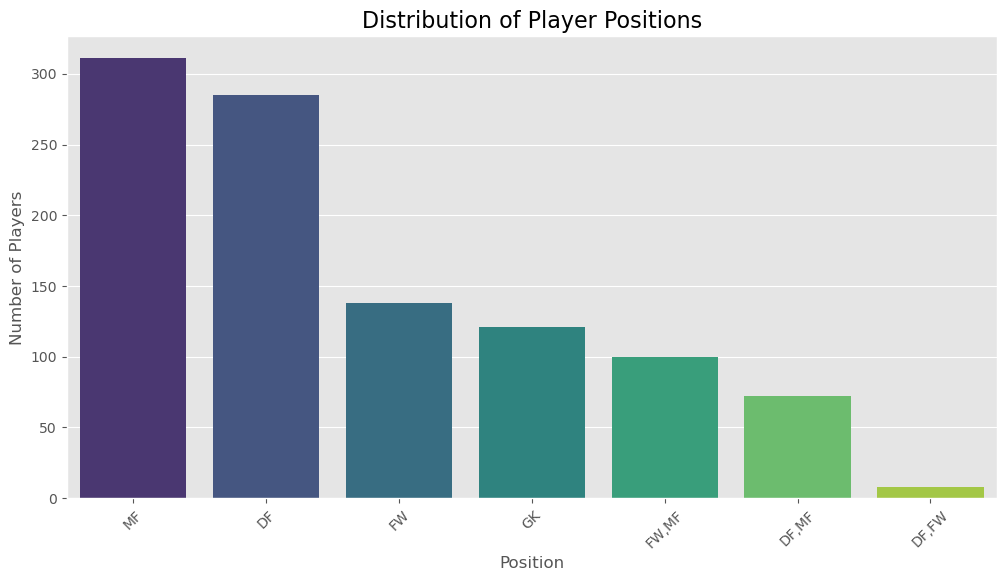

In [15]:
plt.figure(figsize=(12,6))

position_counts = df['position'].value_counts()

sns.barplot(
    x=position_counts.index,
    y=position_counts.values,
    palette='viridis'
)

plt.title("Distribution of Player Positions", fontsize=16)
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.show()

## Top 10 Clubs by Player Count

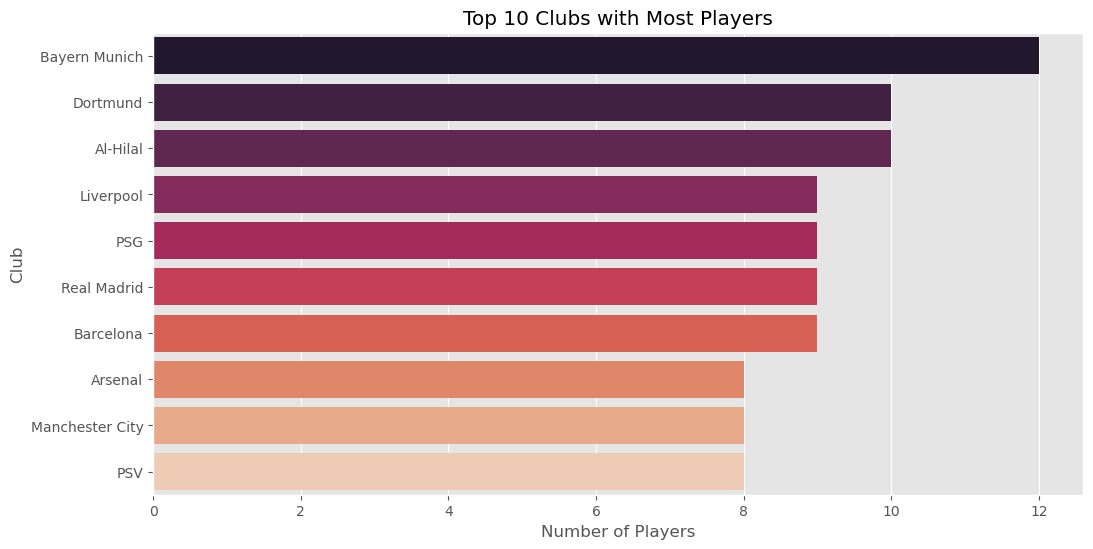

In [16]:
top_clubs = df['club'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_clubs.values,
    y=top_clubs.index,
    palette='rocket'
)

plt.title("Top 10 Clubs with Most Players")
plt.xlabel("Number of Players")
plt.ylabel("Club")

plt.show()

## Top 10 Countries

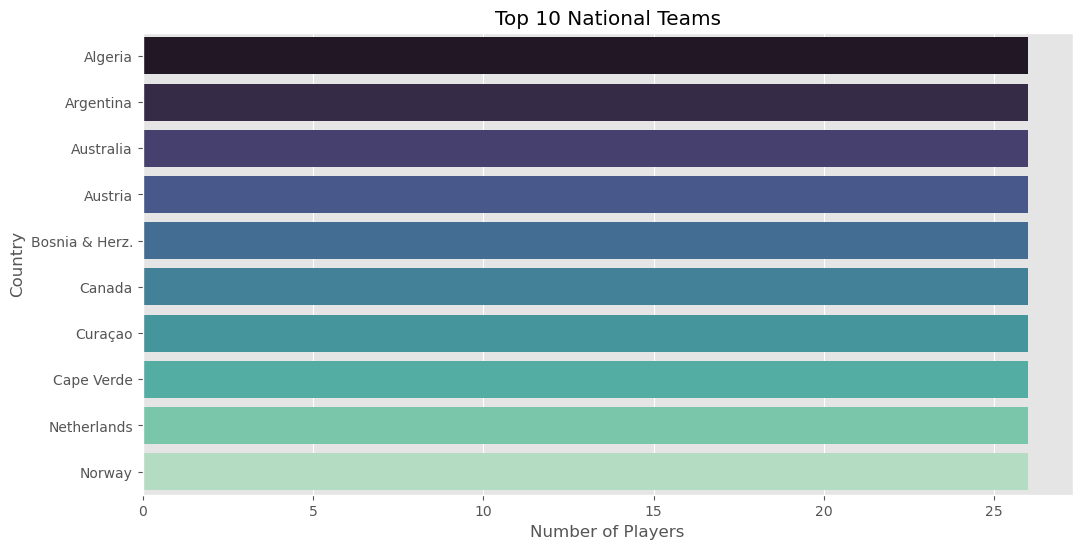

In [17]:
top_countries = df['team'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='mako'
)

plt.title("Top 10 National Teams")
plt.xlabel("Number of Players")
plt.ylabel("Country")

plt.show()

## Top Goal Scorers

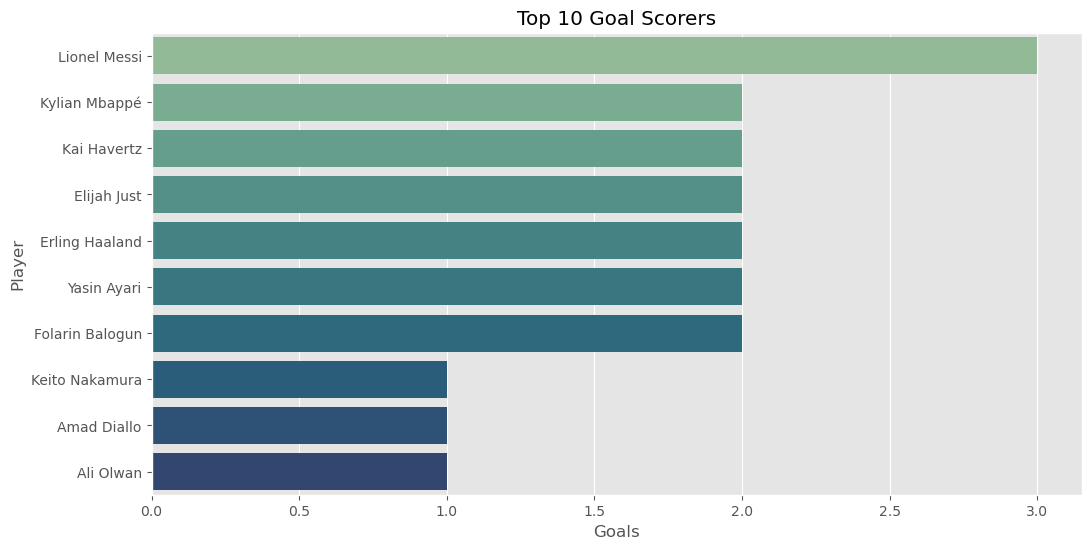

In [18]:
top_goal = df.sort_values(
    by='goals',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='goals',
    y='player',
    data=top_goal,
    palette='crest'
)

plt.title("Top 10 Goal Scorers")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.show()

## Top Assist Providers

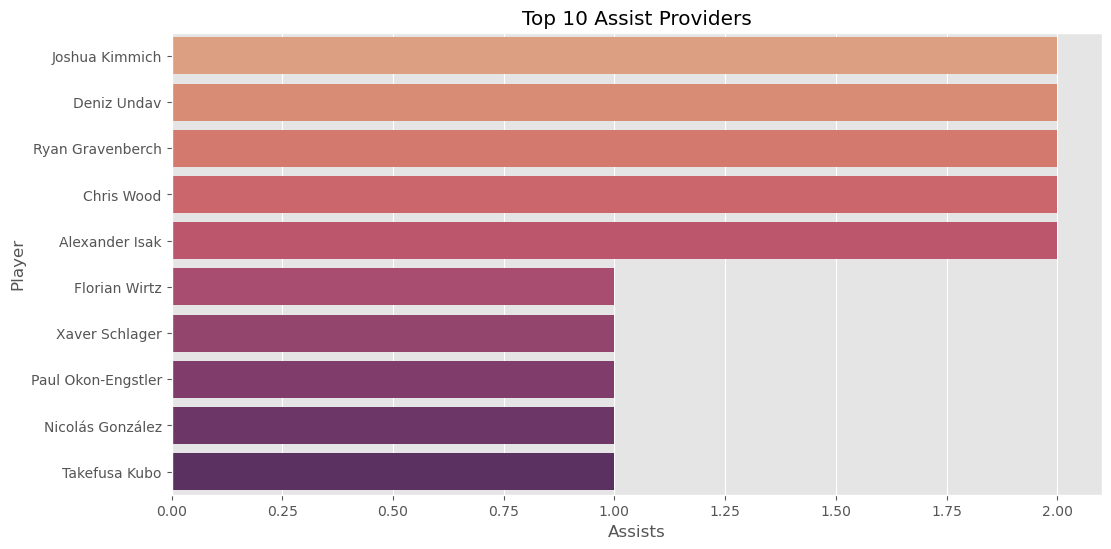

In [19]:
top_assist = df.sort_values(
    by='assists',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='assists',
    y='player',
    data=top_assist,
    palette='flare'
)

plt.title("Top 10 Assist Providers")
plt.xlabel("Assists")
plt.ylabel("Player")

plt.show()

## Goals vs Assists

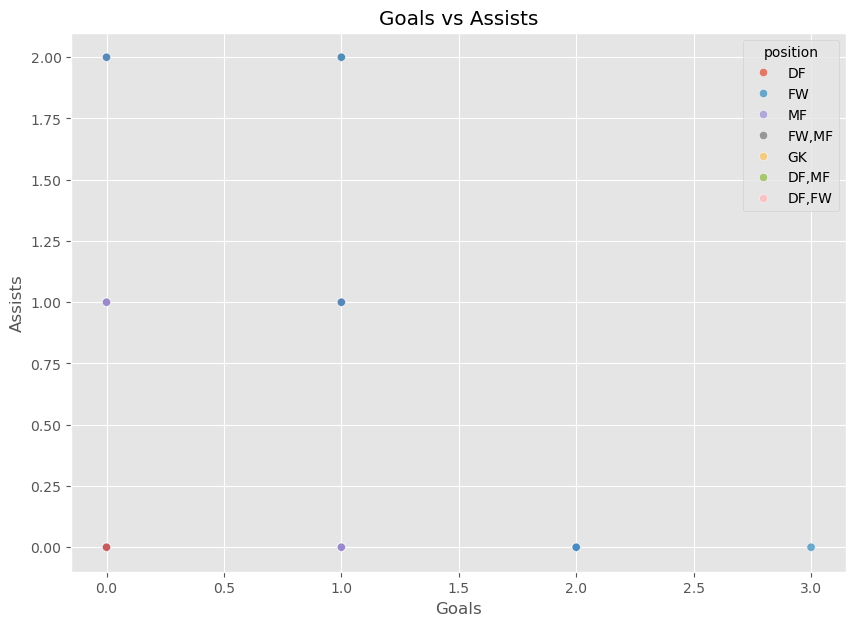

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='goals',
    y='assists',
    hue='position',
    alpha=0.7
)

plt.title("Goals vs Assists")
plt.xlabel("Goals")
plt.ylabel("Assists")

plt.show()

## Correlation Heatmap

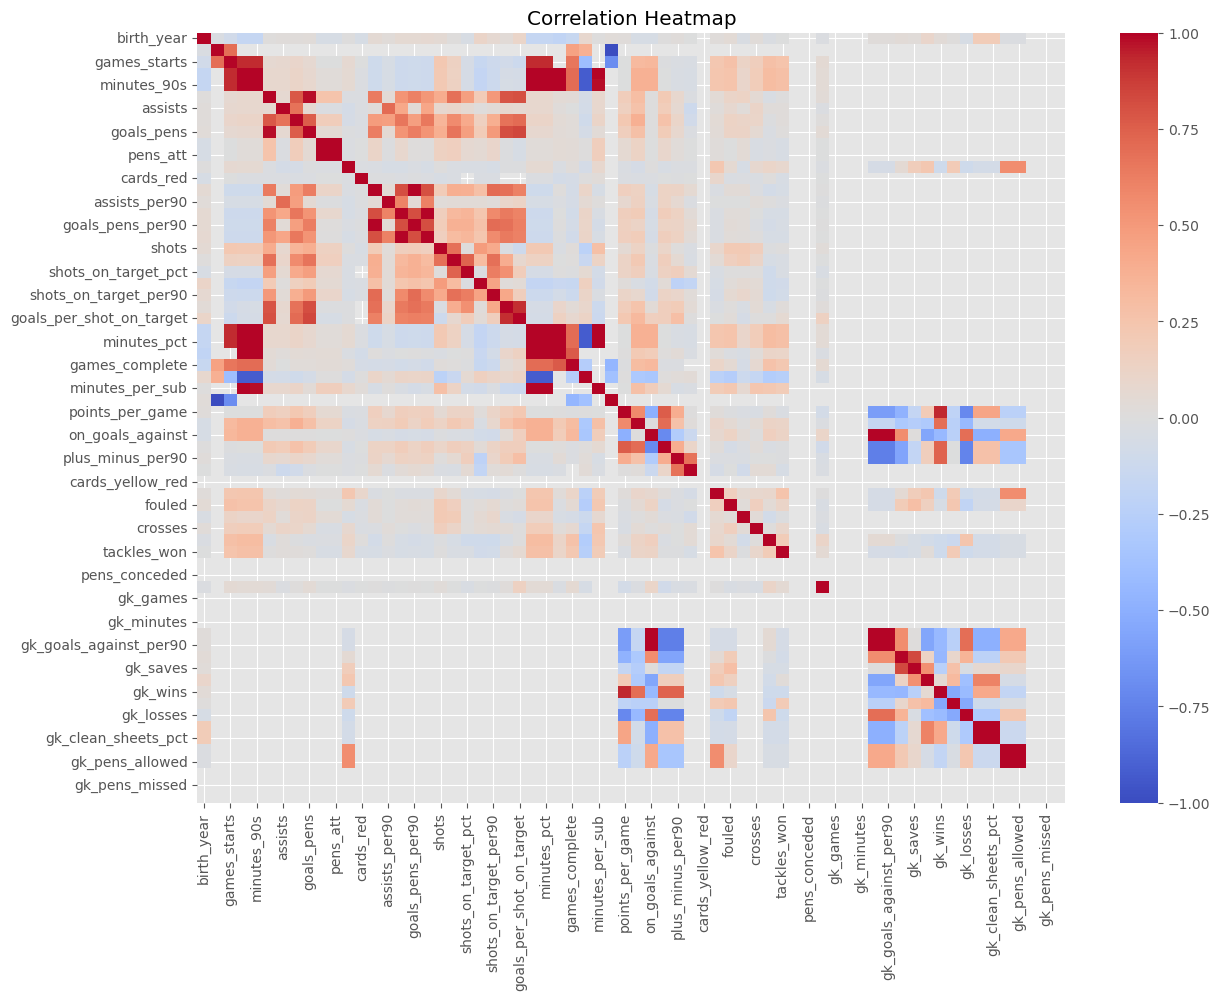

In [22]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight

The heatmap identifies relationships among performance metrics, helping Nike understand which statistics most strongly influence player performance.

## Top Overall Contributors

In [23]:
df['total_contribution'] = df['goals'] + df['assists']

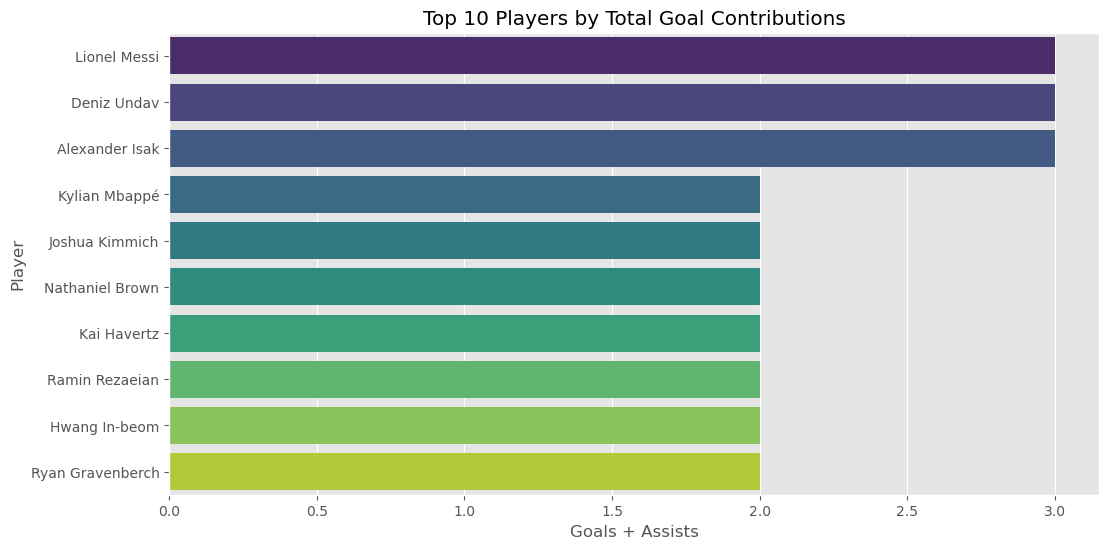

In [24]:
top_players = df.sort_values(
    by='total_contribution',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_players,
    x='total_contribution',
    y='player',
    palette='viridis'
)

plt.title("Top 10 Players by Total Goal Contributions")
plt.xlabel("Goals + Assists")
plt.ylabel("Player")

plt.show()

## Business Insight

Players with the highest combined goals and assists deliver the greatest attacking impact, making them ideal candidates for premium sponsorship opportunities.

# Feature Engineering

## Objective

Create meaningful features that provide deeper insights into player performance and support data-driven sponsorship decisions.

## Create Total Contribution

A player's overall attacking impact can be measured by combining goals and assists.

In [25]:
# Total attacking contribution
df['total_contribution'] = df['goals'] + df['assists']

df[['player', 'goals', 'assists', 'total_contribution']].head()

,player,goals,assists,total_contribution
0,Achref Abada,NaN,NaN,NaN
1,Adil Boulbina,0.0,0.0,0.0
2,Amine Gouiri,0.0,0.0,0.0
3,Anis Hadj Moussa,0.0,0.0,0.0
4,Aïssa Mandi,0.0,0.0,0.0


## Contribution Per Match

This metric measures consistency rather than just total output.

In [26]:
df['contribution_per_match'] = (
    df['total_contribution'] /
    df['games'].replace(0, np.nan)
)

df['contribution_per_match'] = df['contribution_per_match'].fillna(0)

## Goal Efficiency

Measures how efficiently a player converts shots into goals.

In [27]:
df['goal_efficiency'] = (
    df['goals'] /
    df['shots'].replace(0, np.nan)
)

df['goal_efficiency'] = df['goal_efficiency'].fillna(0)

## Assist Efficiency

Measures how frequently a player creates goals.

In [28]:
df['assist_efficiency'] = (
    df['assists'] /
    df['games'].replace(0, np.nan)
)

df['assist_efficiency'] = df['assist_efficiency'].fillna(0)

## Discipline Score

A simple metric to quantify discipline on the field.

In [29]:
df['discipline_score'] = (
    df['cards_yellow'] +
    (2 * df['cards_red'])
)

## Playing Time Percentage

Estimate how much a player participates.

In [31]:
df['minutes_per_game'] = (
    df['minutes'] /
    df['games'].replace(0, np.nan)
)

df['minutes_per_game'] = df['minutes_per_game'].fillna(0)

## Performance Index

Create a comprehensive performance metric.

In [32]:
df['performance_index'] = (
      0.40 * df['contribution_per_match']
    + 0.25 * df['goal_efficiency']
    + 0.20 * df['minutes_per_game']
    - 0.15 * df['discipline_score']
)

In [34]:
new_features = [
    'total_contribution',
    'contribution_per_match',
    'goal_efficiency',
    'assist_efficiency',
    'discipline_score',
    'minutes_per_game',
    'performance_index'
]

df[new_features].head()

,total_contribution,contribution_per_match,goal_efficiency,assist_efficiency,discipline_score,minutes_per_game,performance_index
0,NaN,0.0,0.0,0.0,NaN,0.0,NaN
1,0.0,0.0,0.0,0.0,0.0,10.0,2.0
2,0.0,0.0,0.0,0.0,0.0,63.0,12.6
3,0.0,0.0,0.0,0.0,0.0,63.0,12.6
4,0.0,0.0,0.0,0.0,0.0,90.0,18.0


# Business Modeling (Nike Sponsorship Decision Framework)

We'll build a Nike Sponsorship Score that ranks players based on multiple performance metrics.

In [35]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
features = [
    'contribution_per_match',
    'goal_efficiency',
    'assist_efficiency',
    'minutes_per_game',
    'discipline_score'
]

In [39]:
scaler = MinMaxScaler()

df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df[features])

In [40]:
df_scaled["nike_sponsorship_score"] = (
      0.30 * df_scaled["contribution_per_match"]
    + 0.20 * df_scaled["goal_efficiency"]
    + 0.15 * df_scaled["assist_efficiency"]
    + 0.15 * df_scaled["minutes_per_game"]
    - 0.05 * df_scaled["discipline_score"]
)

In [41]:
df_scaled = df_scaled.sort_values(
    by="nike_sponsorship_score",
    ascending=False
)

df_scaled.reset_index(drop=True, inplace=True)

df_scaled.head()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_pens_saved,gk_pens_missed,gk_pens_save_pct,total_contribution,contribution_per_match,goal_efficiency,assist_efficiency,discipline_score,performance_index,nike_sponsorship_score
0,Deniz Undav,Germany,Germany,"FW,MF",29-333,1996,Stuttgart,1,0,27.0,...,NaN,NaN,NaN,3.0,1.000000,1.000000,1.0,0.0,6.850000,0.695
1,Alexander Isak,Sweden,Sweden,FW,26-269,1999,Liverpool,1,1,89.0,...,NaN,NaN,NaN,3.0,1.000000,0.333333,1.0,0.0,19.083333,0.665
2,Ramin Rezaeian,IR Iran,Iran,DF,36-088,1990,Foolad,1,1,90.0,...,NaN,NaN,NaN,2.0,0.666667,1.000000,0.5,0.0,19.050000,0.625
3,Yasin Ayari,Sweden,Sweden,MF,22-254,2003,Brighton,1,1,90.0,...,NaN,NaN,NaN,2.0,0.666667,1.000000,0.0,0.0,19.050000,0.550
4,Elijah Just,New Zealand,New Zealand,MF,26-047,2000,Motherwell,1,1,90.0,...,NaN,NaN,NaN,2.0,0.666667,1.000000,0.0,0.0,19.050000,0.550


In [42]:
top20 = df_scaled[
    [
        "player",
        "team",
        "club",
        "position",
        "age",
        "nike_sponsorship_score"
    ]
].head(20)

top20

,player,team,club,position,age,nike_sponsorship_score
0,Deniz Undav,Germany,Stuttgart,"FW,MF",29-333,0.695000
1,Alexander Isak,Sweden,Liverpool,FW,26-269,0.665000
2,Ramin Rezaeian,IR Iran,Foolad,DF,36-088,0.625000
3,Yasin Ayari,Sweden,Brighton,MF,22-254,0.550000
4,Elijah Just,New Zealand,Motherwell,MF,26-047,0.550000
5,Lionel Messi,Argentina,Inter Miami,FW,38-358,0.531667
6,Chris Wood,New Zealand,Nottingham,FW,34-192,0.500000
7,Nathaniel Brown,Germany,Frankfurt,DF,23-001,0.495000
8,Joshua Kimmich,Germany,Bayern Munich,DF,31-129,0.486667
9,Ryan Gravenberch,Netherlands,Liverpool,MF,24-032,0.483333


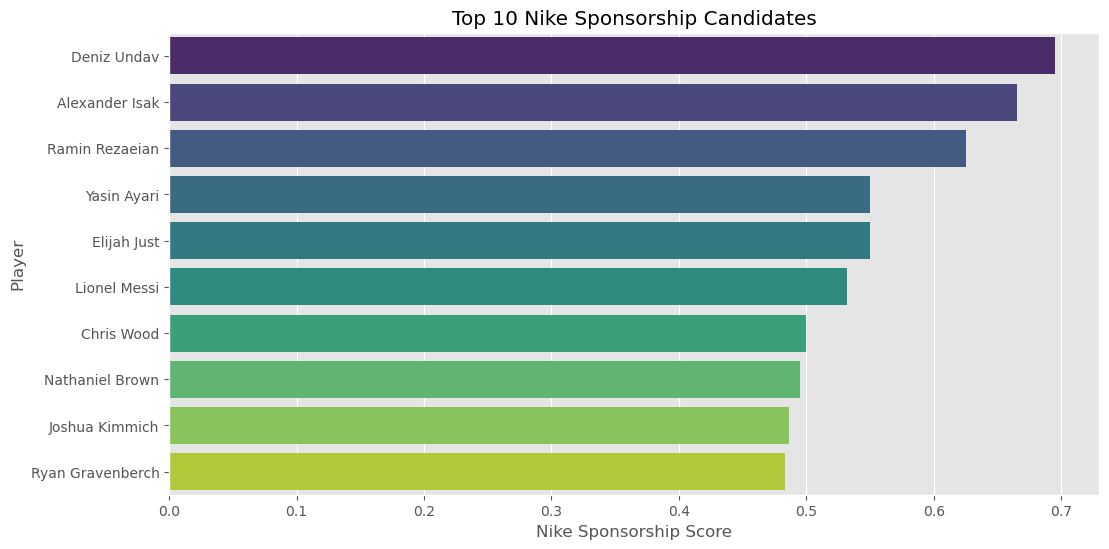

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top20.head(10),
    x="nike_sponsorship_score",
    y="player",
    palette="viridis"
)

plt.title("Top 10 Nike Sponsorship Candidates")
plt.xlabel("Nike Sponsorship Score")
plt.ylabel("Player")

plt.show()

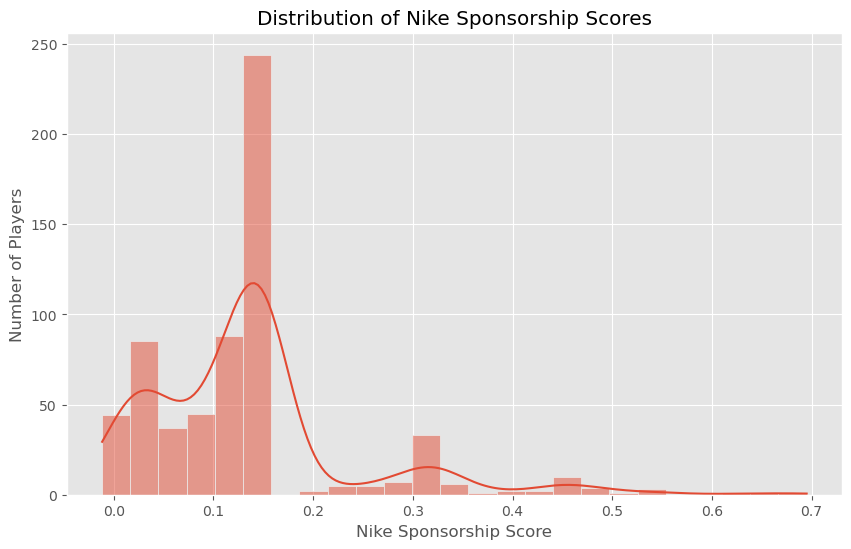

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_scaled["nike_sponsorship_score"],
    bins=25,
    kde=True
)

plt.title("Distribution of Nike Sponsorship Scores")
plt.xlabel("Nike Sponsorship Score")
plt.ylabel("Number of Players")

plt.show()

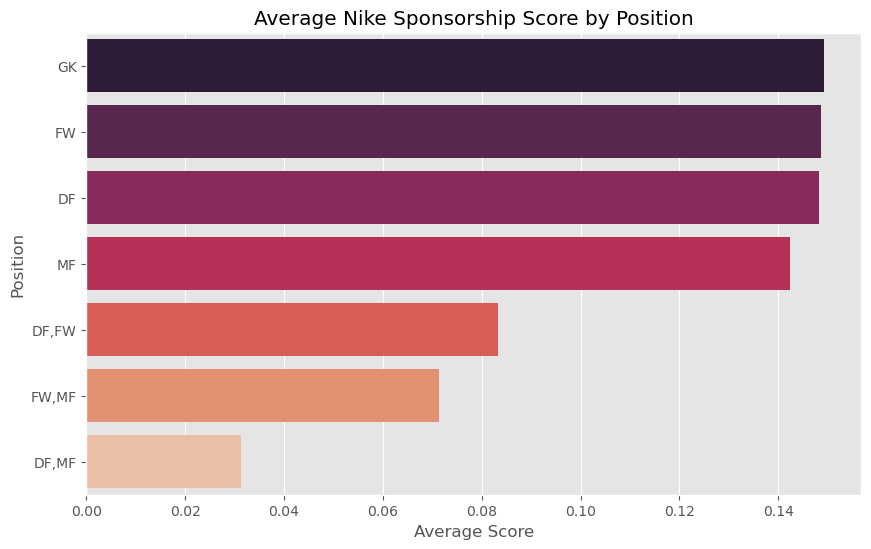

In [45]:
position_score = (
    df_scaled
    .groupby("position")["nike_sponsorship_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=position_score.values,
    y=position_score.index,
    palette="rocket"
)

plt.title("Average Nike Sponsorship Score by Position")
plt.xlabel("Average Score")
plt.ylabel("Position")

plt.show()

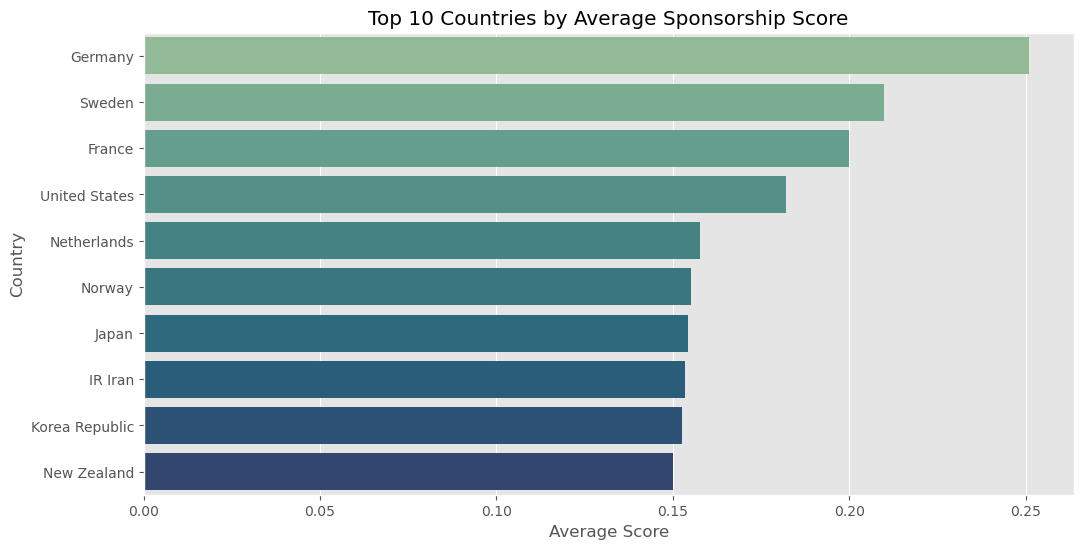

In [46]:
country_score = (
    df_scaled
    .groupby("team")["nike_sponsorship_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_score.values,
    y=country_score.index,
    palette="crest"
)

plt.title("Top 10 Countries by Average Sponsorship Score")
plt.xlabel("Average Score")
plt.ylabel("Country")

plt.show()